#  Pipeline de Machine Learning — Dataset de Qualidade Ambiental


**Dataset:** Monitoramento Ambiental — 10.000 registros, 8 features, 5 classes  
**Objetivo:** Classificar a Qualidade Ambiental com base em sensores de temperatura, umidade, gases e pressão atmosférica.

---

##  Estrutura do Notebook

| # | Seção | Descrição |
|---|-------|-----------|
| 1 | Importação e Configuração | Libs, seeds, warnings |
| 2 | Carregamento dos Dados | CSV → DataFrame |
| 3 | EDA | Profiling, correlação, outliers |
| 4 | Pré-processamento | Limpeza, encoding, SMOTE |
| 5 | Benchmark de Modelos | LazyPredict |
| 6 | Otimização (Optuna) | Tuning de hiperparâmetros |
| 7 | Treinamento Final | Métricas e avaliação |
| 8 | MLflow Tracking | Rastreamento de experimentos |
| 9 | Salvamento de Artefatos | joblib, pkl |
| 10 | Conclusão | Insights e próximos passos |

---
#  1. Importação e Configuração

Carregamos todas as bibliotecas necessárias para o pipeline completo. O seed global (`RANDOM_STATE = 42`) garante **reprodutibilidade** em todas as etapas — do split ao Optuna.

> **Por que fixar o seed?** Em modelos estocásticos (árvores, SMOTE, split), resultados variam a cada execução. O seed elimina essa variância e permite comparações justas entre experimentos.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# Instalação de bibliotecas adicionais (necessário em ambientes limpos)
# ─────────────────────────────────────────────────────────────────
!pip install -q ydata-profiling optuna mlflow lazypredict imbalanced-learn joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


import mlflow
import mlflow.sklearn


import joblib


from lazypredict.Supervised import LazyClassifier


from ydata_profiling import ProfileReport

# ─────────────────────────────────────────────────────────────────
# CONFIGURAÇÕES GLOBAIS
# ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.20
N_SPLITS     = 5
OPTUNA_TRIALS = 50

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Estilo de visualização
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
sns.set_palette('husl')

print(f' Ambiente configurado | Seed: {RANDOM_STATE} | {datetime.now().strftime("%Y-%m-%d %H:%M")}')

 Ambiente configurado | Seed: 42 | 2026-03-25 18:27


---
#  2. Carregamento dos Dados

O dataset contém **10.000 registros** com 8 variáveis preditoras (sensores ambientais) e 1 variável alvo (`Qualidade_Ambiental`). Realizamos uma inspeção inicial de 3 camadas:

1. **Estrutura** — shape, dtypes
2. **Conteúdo** — head, describe
3. **Qualidade** — nulos, duplicados, cardinalidade do target

In [ ]:
DATA_PATH = 'dataset_ambiental.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f' Shape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas')
print(f' Duplicatas: {df_raw.duplicated().sum()}')
print()
df_raw.head()

 Shape: 10,000 linhas × 9 colunas
 Duplicatas: 0



,Temperatura,Umidade,CO2,CO,Pressao_Atm,NO2,SO2,O3,Qualidade_Ambiental
0,21.236204,46.154857,1540.997129,31.907228,979.8912041204417,85.487475,37.336205,14.692721,Moderada
1,38.521429,43.303847,613.670393,22.964623,959.4817775162059,51.979119,44.173992,101.135508,Moderada
2,31.959818,32.330774,19998.316609,48.224926,962.6359224972216,23.569233,23.695814,37.423834,Moderada
3,27.959755,62.508667,1427.577083,10.948923,968.0671128180921,74.980970,15.169758,41.233110,Moderada
4,14.680559,53.363691,1119.551886,29.392821,970.3653334364949,44.774423,16.623482,34.886981,Moderada


In [ ]:
# Informações de tipo e nulos
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Temperatura          9900 non-null   float64
 1   Umidade              9800 non-null   float64
 2   CO2                  10000 non-null  float64
 3   CO                   10000 non-null  float64
 4   Pressao_Atm          10000 non-null  object 
 5   NO2                  10000 non-null  float64
 6   SO2                  10000 non-null  float64
 7   O3                   10000 non-null  float64
 8   Qualidade_Ambiental  10000 non-null  object 
dtypes: float64(7), object(2)
memory usage: 703.3+ KB


In [ ]:
# descritivas
df_raw.describe(include='all').T.style.background_gradient(cmap='Blues', axis=0)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temperatura,9900.000000,nan,nan,nan,24.818747,8.627029,10.000349,17.386090,24.775593,32.175026,39.991530
Umidade,9800.000000,nan,nan,nan,55.308556,20.243330,20.011042,37.780522,55.380697,72.899768,89.994738
CO2,10000.000000,nan,nan,nan,1526.799620,2682.748551,300.081811,739.875009,1168.936432,1592.929532,19998.316609
CO,10000.000000,nan,nan,nan,24.935669,14.449730,0.000277,12.342862,25.001512,37.355813,49.989469
Pressao_Atm,10000,9901,erro_sensor,100,nan,nan,nan,nan,nan,nan,nan
NO2,10000.000000,nan,nan,nan,52.798736,27.392422,5.000801,29.410865,53.078587,76.577367,99.994271
SO2,10000.000000,nan,nan,nan,25.587618,14.095238,1.013236,13.440352,25.706263,37.870990,49.984804
O3,10000.000000,nan,nan,nan,64.914693,31.456487,10.014301,37.719825,64.915458,92.260420,119.986261
Qualidade_Ambiental,10000,5,Moderada,5912,nan,nan,nan,nan,nan,nan,nan


In [ ]:
# Distribuição do target
target_counts = df_raw['Qualidade_Ambiental'].value_counts()
print(' Distribuição do Target:')
print(target_counts.to_string())
print(f'\nRatio Majority/Minority: {target_counts.max() / target_counts.min():.1f}x  ← forte desbalanceamento!')

 Distribuição do Target:
Qualidade_Ambiental
Moderada      5912
Ruim          2569
Boa           1453
Muito Ruim      55
Excelente       11

Ratio Majority/Minority: 537.5x  ← forte desbalanceamento!


In [ ]:
# Tabela de valores nulos
null_df = pd.DataFrame({
    'Nulos': df_raw.isnull().sum(),
    '% Nulos': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
null_df[null_df['Nulos'] > 0].style.background_gradient(cmap='Reds')

,Nulos,% Nulos
Temperatura,100,1.000000
Umidade,200,2.000000


---
# 3. Análise Exploratória de Dados (EDA)

A EDA é a etapa mais importante do projeto. Aqui entendemos a estrutura dos dados, identificamos problemas e definimos estratégias de pré-processamento.

**Camadas da EDA:**
- 📋 Relatório automático com `ydata-profiling`
- 📈 Distribuição univariada (histogramas + KDE)
- 🔗 Correlação entre features
- 🎯 Análise por classe do target
- 📦 Detecção de outliers (boxplots + IQR)
- ⚠️ Mapa de nulos

In [ ]:
profile = ProfileReport(
    df_raw,
    title='EDA — Dataset Ambiental',
    explorative=True,
    minimal=False
)
profile.to_file('eda_report.html')   # salva relatório HTML
profile.to_notebook_iframe()         # exibe no notebook

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:00<00:00, 20.74it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 3b. DISTRIBUIÇÃO UNIVARIADA

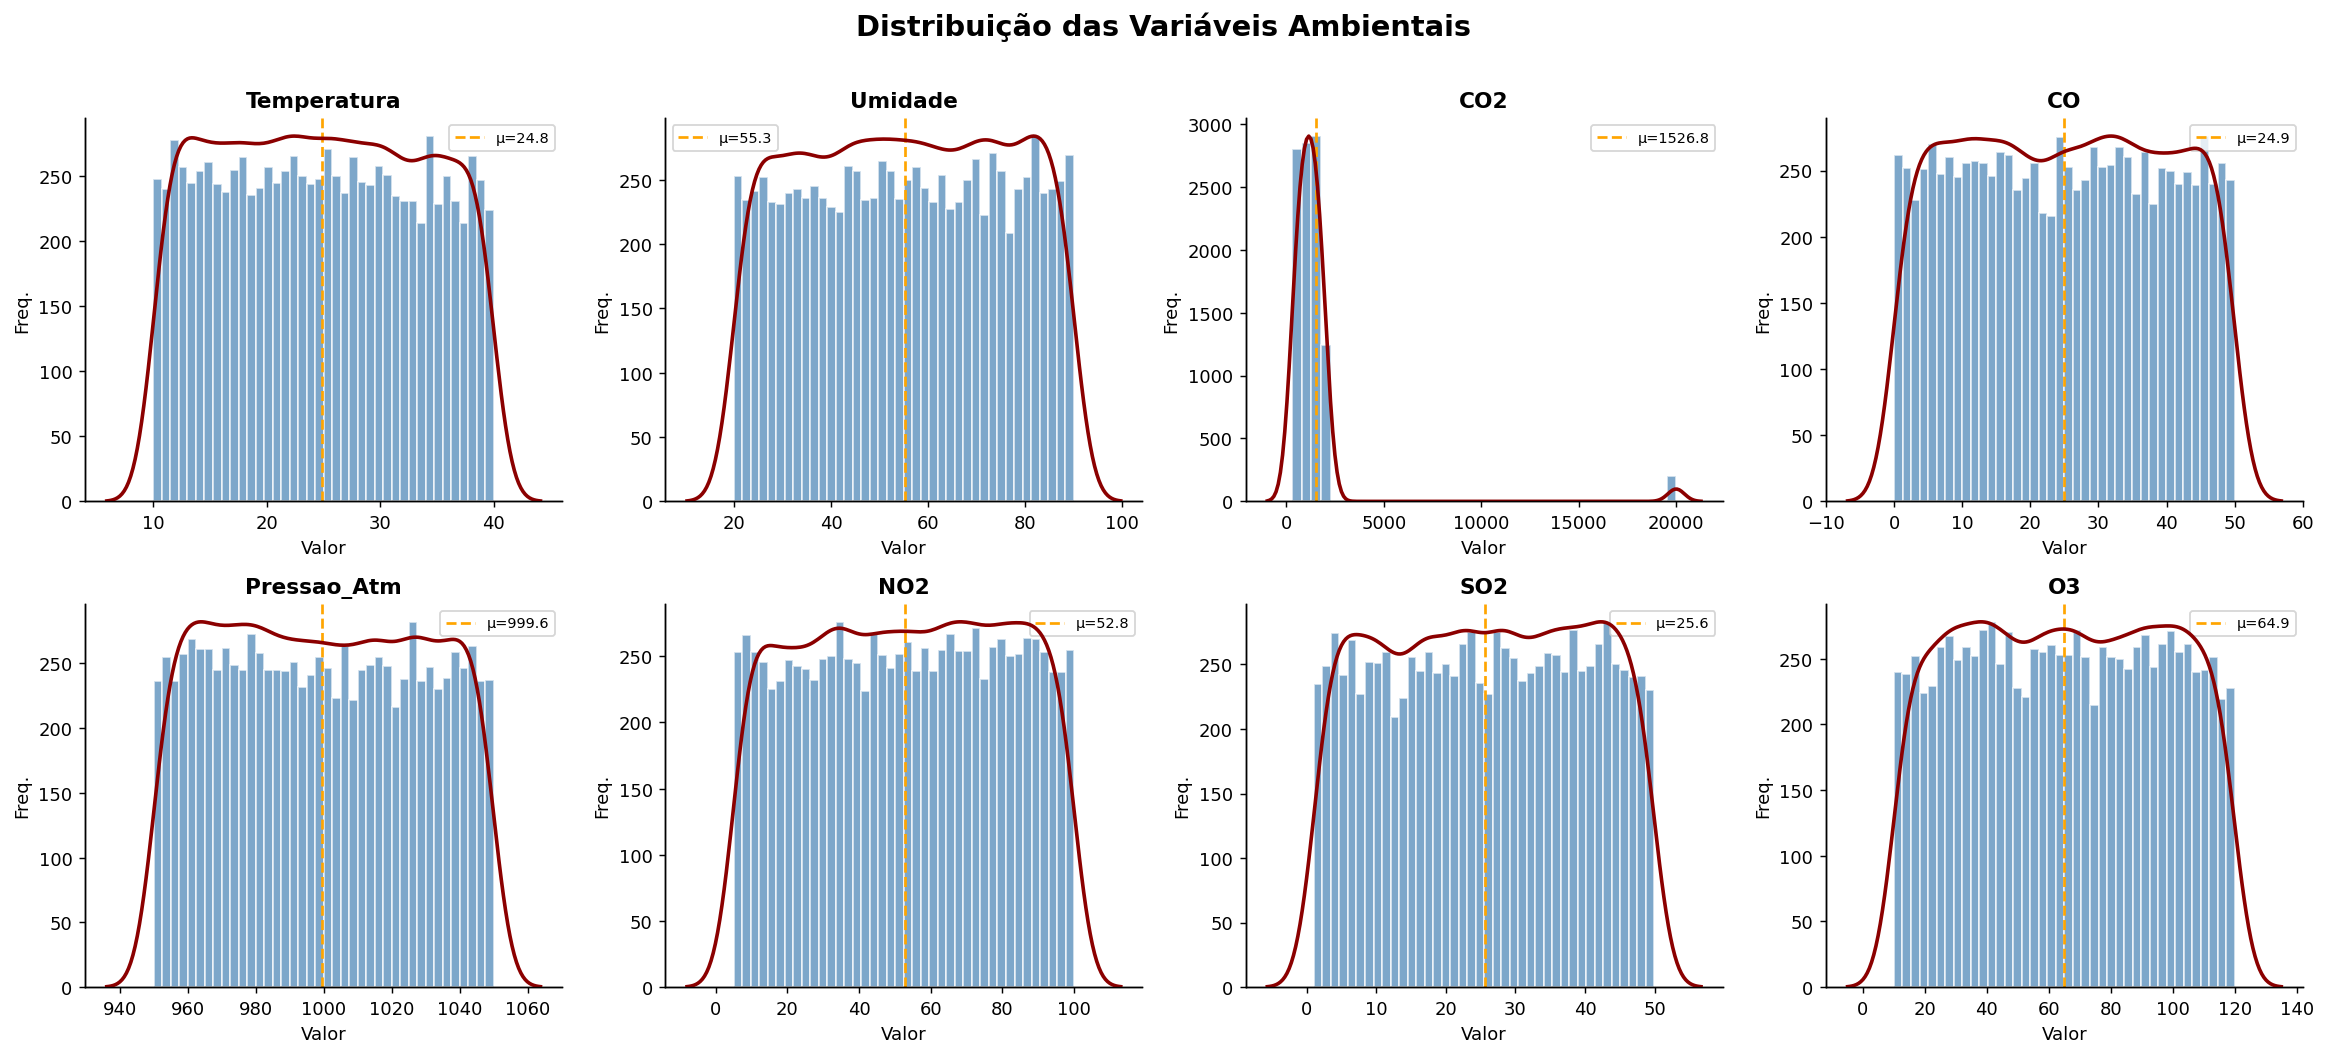

In [ ]:
features = [c for c in df_raw.columns if c != 'Qualidade_Ambiental']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    data = pd.to_numeric(df_raw[feat], errors='coerce').dropna()
    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax2 = ax.twinx()
    sns.kdeplot(data, ax=ax2, color='darkred', linewidth=2)
    ax2.set_ylabel('')
    ax2.set_yticks([])
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Freq.')
    # Linha de média
    ax.axvline(data.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Ambientais', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuicoes.png', bbox_inches='tight')
plt.show()

# 3c. DISTRIBUIÇÃO DO TARGET (desbalanceamento)

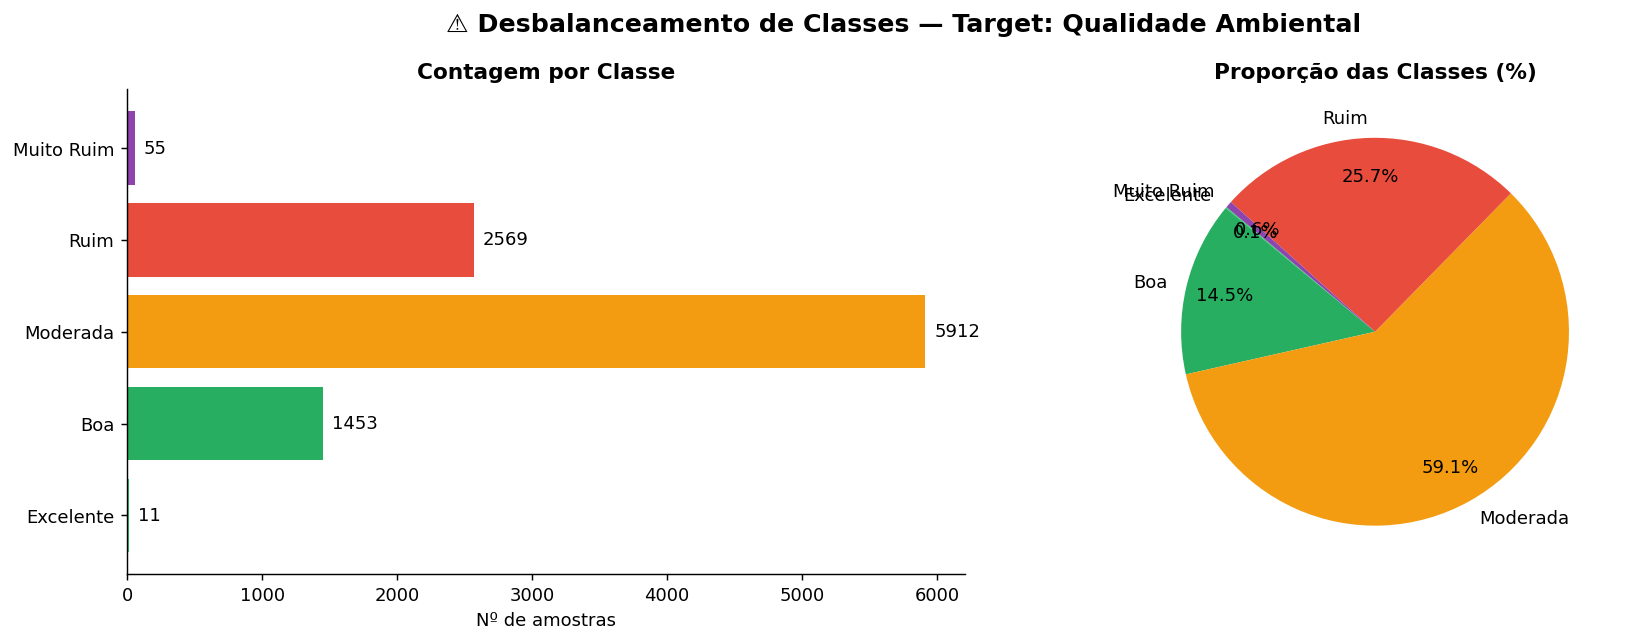

In [ ]:
ordem = ['Excelente', 'Boa', 'Moderada', 'Ruim', 'Muito Ruim']
cores = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#8e44ad']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Barras
counts = df_raw['Qualidade_Ambiental'].value_counts().reindex(ordem, fill_value=0)
bars = ax1.barh(counts.index, counts.values, color=cores)
ax1.bar_label(bars, fmt='%d', padding=5)
ax1.set_title('Contagem por Classe', fontweight='bold')
ax1.set_xlabel('Nº de amostras')

# Pizza
ax2.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=cores, startangle=140, pctdistance=0.8)
ax2.set_title('Proporção das Classes (%)', fontweight='bold')

plt.suptitle(' Desbalanceamento de Classes — Target: Qualidade Ambiental',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('target_distribuicao.png', bbox_inches='tight')
plt.show()

# 3d. MATRIZ DE CORRELAÇÃO

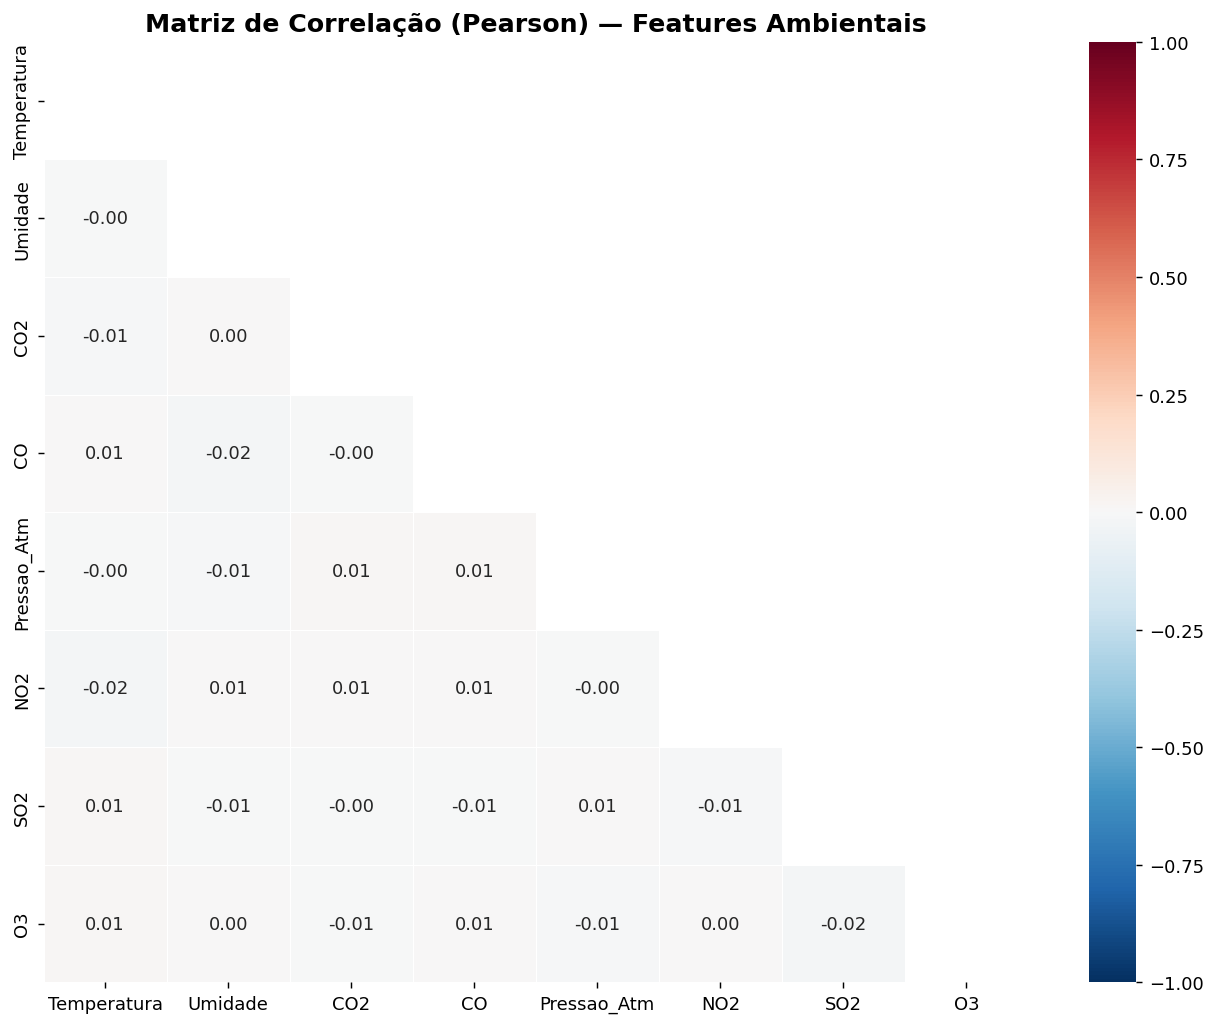


 Pares com correlação |r| > 0.5:


In [ ]:
df_num = df_raw[features].apply(pd.to_numeric, errors='coerce')
corr = df_num.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, ax=ax,
    annot_kws={'size': 10}, linewidths=0.5
)
ax.set_title('Matriz de Correlação (Pearson) — Features Ambientais', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlacao.png', bbox_inches='tight')
plt.show()

# Pares de alta correlação
print('\n Pares com correlação |r| > 0.5:')
high = (corr.abs().where(~mask) > 0.5).stack()
high = high[high].index.tolist()
for a, b in high:
    print(f'   {a} × {b}: r = {corr.loc[a, b]:.3f}')

# 3e. OUTLIERS — Boxplots por classe

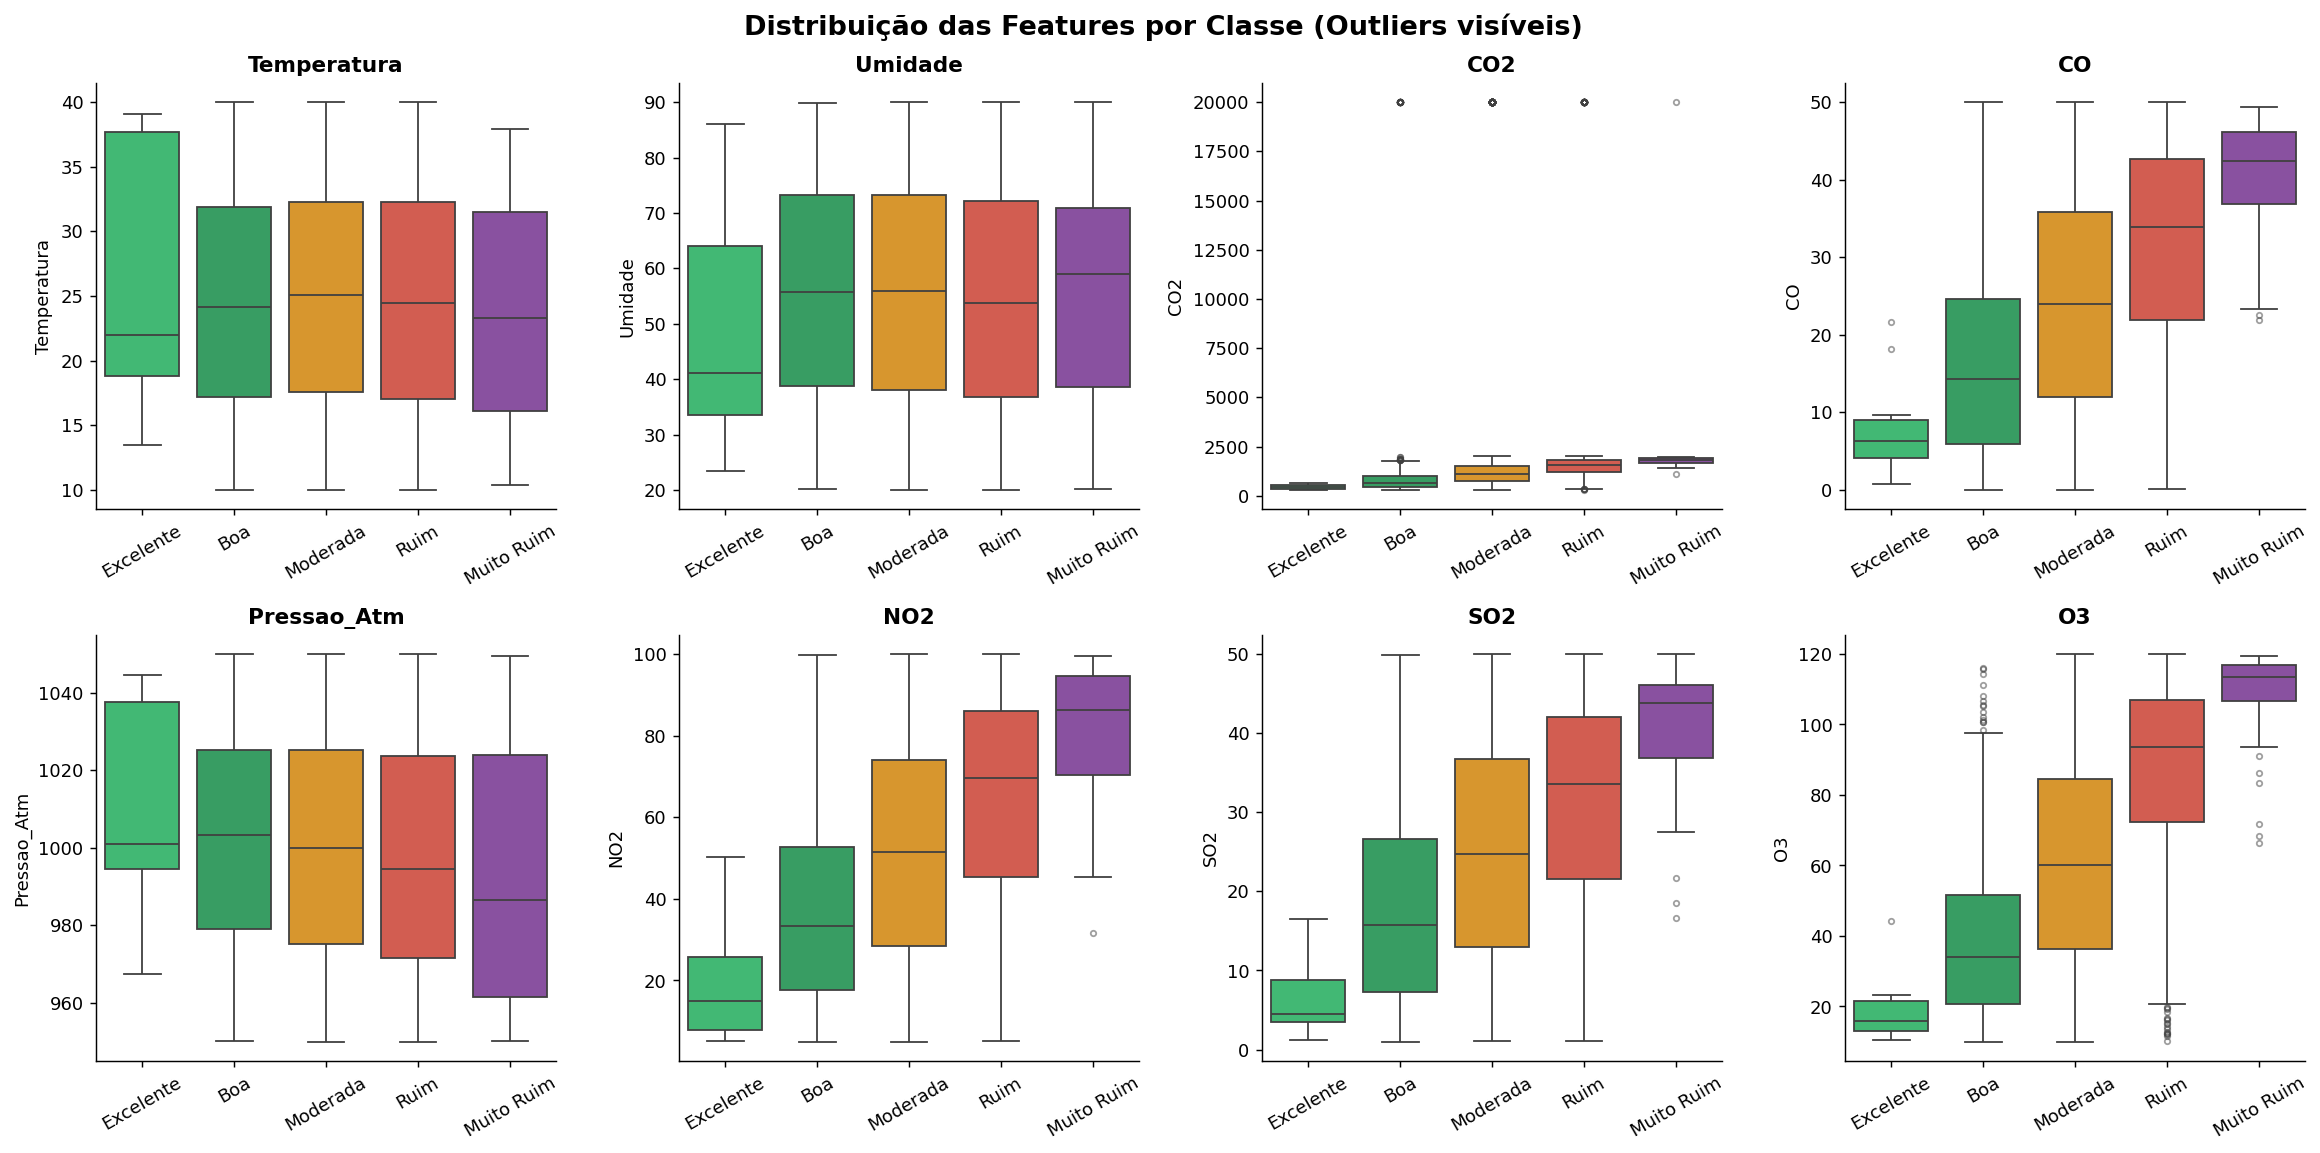

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

palette = {'Excelente': '#2ecc71', 'Boa': '#27ae60',
           'Moderada': '#f39c12', 'Ruim': '#e74c3c', 'Muito Ruim': '#8e44ad'}

for i, feat in enumerate(features):
    df_plot = df_raw[[feat, 'Qualidade_Ambiental']].copy()
    df_plot[feat] = pd.to_numeric(df_plot[feat], errors='coerce')
    sns.boxplot(
        data=df_plot, x='Qualidade_Ambiental', y=feat,
        order=ordem, palette=palette, ax=axes[i],
        flierprops={'markersize': 3, 'alpha': 0.5}
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribuição das Features por Classe (Outliers visíveis)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots_classes.png', bbox_inches='tight')
plt.show()

# 3f. MAPA DE VALORES NULOS

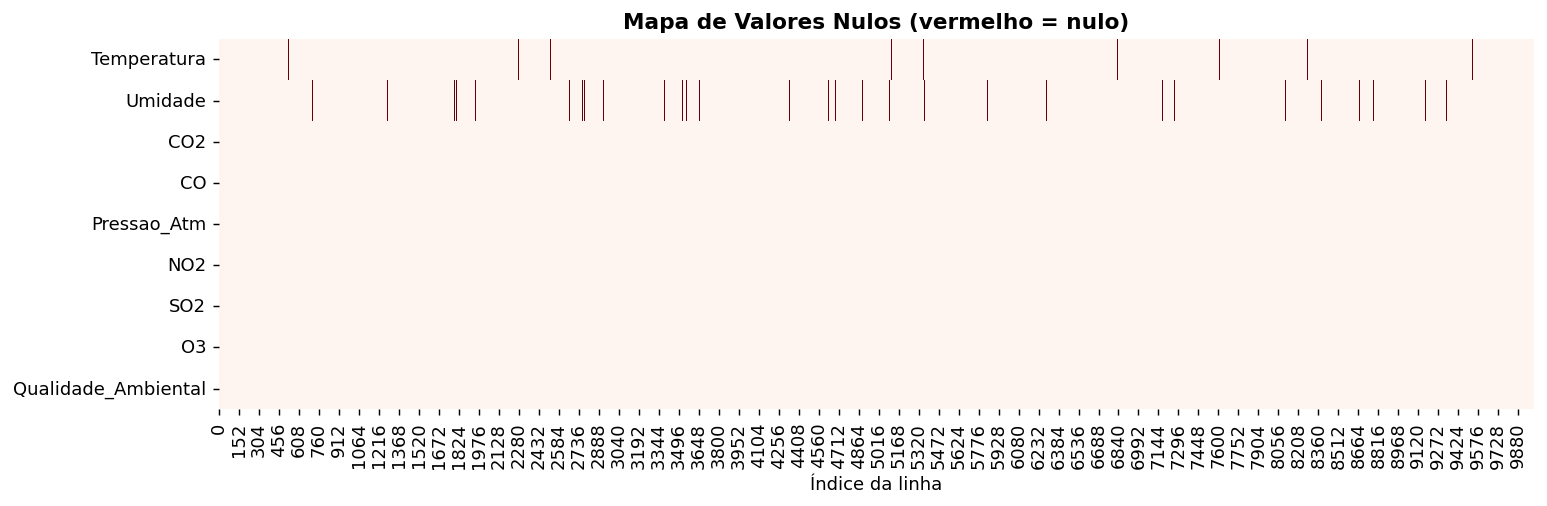


 Resumo de Nulos:
             Nulos  % Nulos
Temperatura    100      1.0
Umidade        200      2.0


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
null_matrix = df_raw.isnull().astype(int)
sns.heatmap(null_matrix.T, cbar=False, cmap='Reds', ax=ax, yticklabels=df_raw.columns)
ax.set_title('Mapa de Valores Nulos (vermelho = nulo)', fontweight='bold')
ax.set_xlabel('Índice da linha')
plt.tight_layout()
plt.savefig('mapa_nulos.png', bbox_inches='tight')
plt.show()

print('\n Resumo de Nulos:')
print(null_df[null_df['Nulos'] > 0].to_string() if null_df['Nulos'].sum() > 0 else '  Nenhum nulo encontrado.')

# 3g. DETECÇÃO DE OUTLIERS — Método IQR

In [ ]:

outlier_report = {}
for feat in features:
    col = pd.to_numeric(df_raw[feat], errors='coerce').dropna()
    Q1, Q3 = col.quantile(0.25), col.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)).sum()
    outlier_report[feat] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Outliers': n_out,
                            '% Outliers': round(n_out / len(col) * 100, 2)}

outlier_df = pd.DataFrame(outlier_report).T
print('📦 Relatório de Outliers (IQR):')
outlier_df.style.background_gradient(subset=['% Outliers'], cmap='YlOrRd')

📦 Relatório de Outliers (IQR):


,Q1,Q3,IQR,Outliers,% Outliers
Temperatura,17.386090,32.175026,14.788937,0.000000,0.000000
Umidade,37.780522,72.899768,35.119246,0.000000,0.000000
CO2,739.875009,1592.929532,853.054524,200.000000,2.000000
CO,12.342862,37.355813,25.012950,0.000000,0.000000
Pressao_Atm,974.364660,1025.002687,50.638027,0.000000,0.000000
NO2,29.410865,76.577367,47.166502,0.000000,0.000000
SO2,13.440352,37.870990,24.430638,0.000000,0.000000
O3,37.719825,92.260420,54.540595,0.000000,0.000000


# 3h. PAIRPLOT — Relação entre as principais features

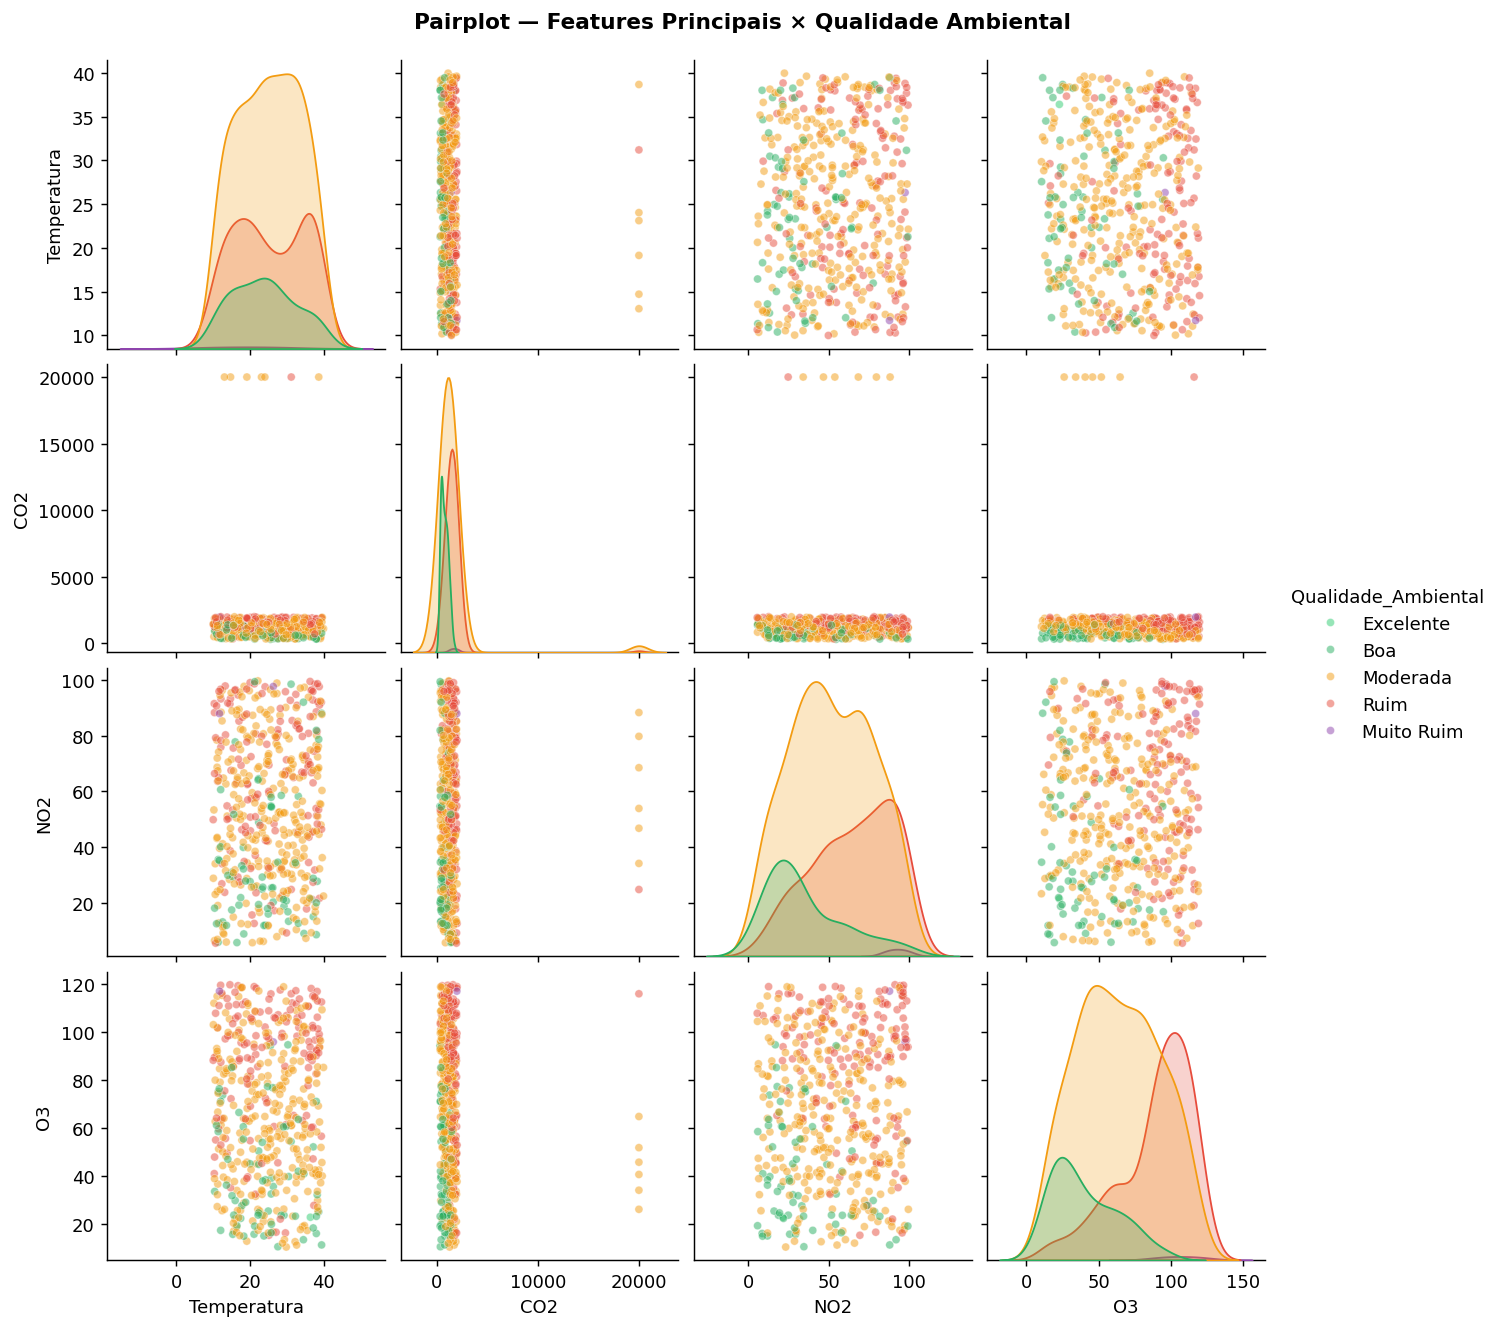

In [ ]:
# Usar sample para não sobrecarregar
df_sample = df_raw.sample(500, random_state=RANDOM_STATE)
top_feats = ['Temperatura', 'CO2', 'NO2', 'O3', 'Qualidade_Ambiental']

pp = sns.pairplot(
    df_sample[top_feats],
    hue='Qualidade_Ambiental',
    hue_order=ordem,
    palette=palette,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20}
)
pp.fig.suptitle('Pairplot — Features Principais × Qualidade Ambiental', y=1.02, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

---
#  4. Pré-processamento de Dados

O pré-processamento é cuidadosamente estruturado para **evitar data leakage**:

```
DataFrame bruto
    │
    ├─ to_numeric (coerce) → forçar tipos numéricos
    ├─ SimpleImputer (median) → imputar nulos
    ├─ StandardScaler → normalizar features
    │
    └─ train_test_split (stratify)
         │
         ├─ X_train → SMOTE → X_train_balanced  ← fit do scaler/imputer AQUI
         └─ X_test  → apenas transform
```

>  **Regra de ouro:** nunca aplique `fit()` no conjunto de teste. O `SMOTE` é aplicado **apenas no treino** para não contaminar a avaliação.

# 4. PRÉ-PROCESSAMENTO

In [ ]:
# 4a. Cópia de trabalho e conversão de tipos
df = df_raw.copy()
for feat in features:
    df[feat] = pd.to_numeric(df[feat], errors='coerce')

# 4b. Separar X e y
X = df[features].copy()
y = df['Qualidade_Ambiental'].copy()

# 4c. Encoding do target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes codificadas:', dict(zip(le.classes_, le.transform(le.classes_))))

# 4d. Split treino/teste (stratify para preservar proporção de classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_enc
)
print(f'\n  Split: {len(X_train):,} treino | {len(X_test):,} teste')

# 4e. Pipeline de pré-processamento (fit apenas no treino!)
preproc_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_proc = preproc_pipeline.fit_transform(X_train)   # FIT + TRANSFORM
X_test_proc  = preproc_pipeline.transform(X_test)         # apenas TRANSFORM

print(f'\n Pré-processamento OK | Shape treino: {X_train_proc.shape}')

Classes codificadas: {'Boa': np.int64(0), 'Excelente': np.int64(1), 'Moderada': np.int64(2), 'Muito Ruim': np.int64(3), 'Ruim': np.int64(4)}

  Split: 8,000 treino | 2,000 teste

 Pré-processamento OK | Shape treino: (8000, 8)


# 4f. SMOTE — Balanceamento do conjunto de TREINO

In [ ]:
print('Distribuição ANTES do SMOTE (treino):')
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique), counts):
    print(f'  {cls}: {cnt}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print('\nDistribuição APÓS o SMOTE (treino):')
unique2, counts2 = np.unique(y_train_bal, return_counts=True)
for cls, cnt in zip(le.inverse_transform(unique2), counts2):
    print(f'  {cls}: {cnt}')
print(f'\n SMOTE: {len(X_train)} → {len(X_train_bal)} amostras de treino')

Distribuição ANTES do SMOTE (treino):
  Boa: 1162
  Excelente: 9
  Moderada: 4730
  Muito Ruim: 44
  Ruim: 2055

Distribuição APÓS o SMOTE (treino):
  Boa: 4730
  Excelente: 4730
  Moderada: 4730
  Muito Ruim: 4730
  Ruim: 4730

 SMOTE: 8000 → 23650 amostras de treino


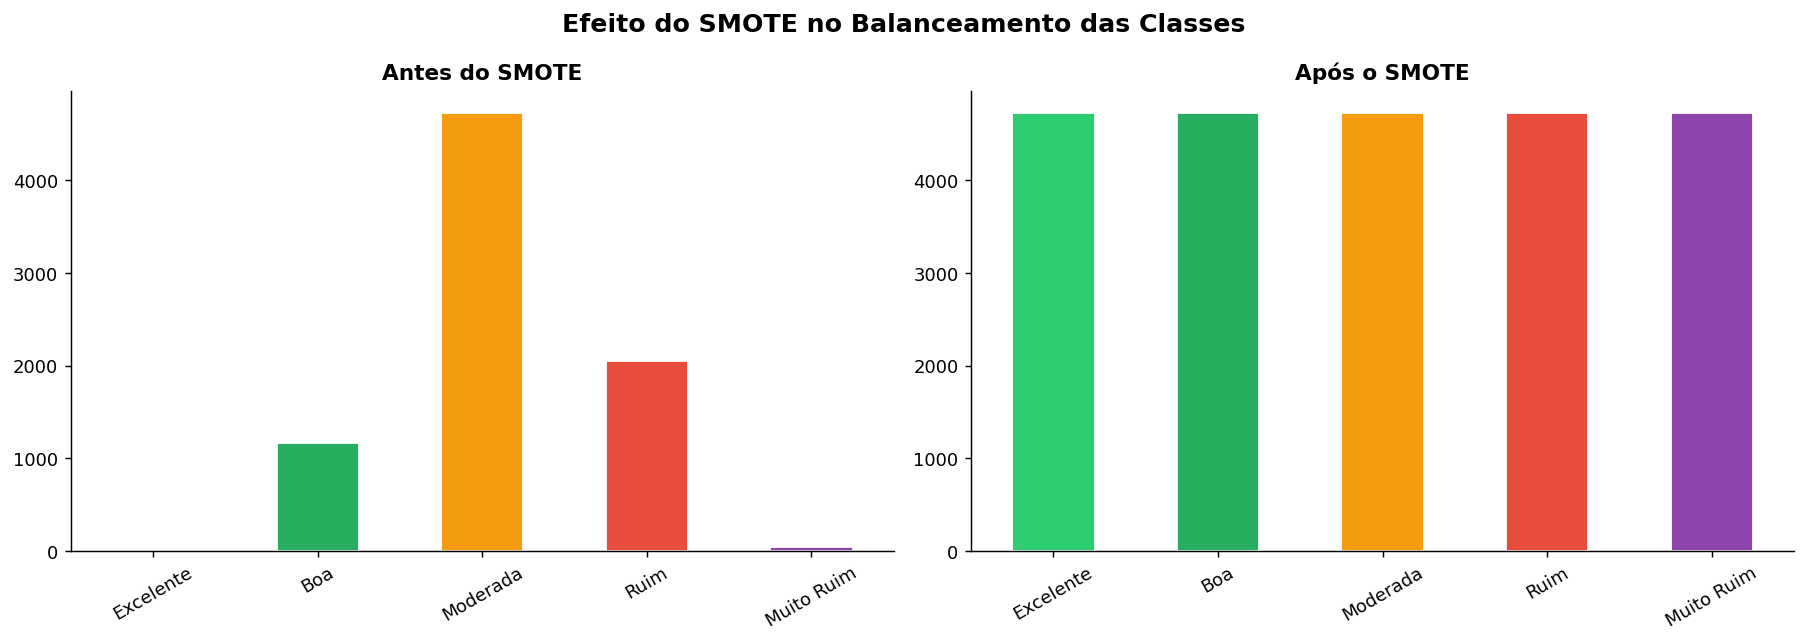

In [ ]:
# Visualizar efeito do SMOTE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

before = pd.Series(y_train).map(dict(zip(range(len(le.classes_)), le.classes_))).value_counts().reindex(ordem, fill_value=0)
after  = pd.Series(y_train_bal).map(dict(zip(range(len(le.classes_)), le.classes_))).value_counts().reindex(ordem, fill_value=0)

before.plot(kind='bar', ax=ax1, color=cores, edgecolor='white')
ax1.set_title('Antes do SMOTE', fontweight='bold'); ax1.set_xlabel(''); ax1.tick_params(axis='x', rotation=30)

after.plot(kind='bar', ax=ax2, color=cores, edgecolor='white')
ax2.set_title('Após o SMOTE', fontweight='bold'); ax2.set_xlabel(''); ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Efeito do SMOTE no Balanceamento das Classes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_balanceamento.png', bbox_inches='tight')
plt.show()

---
#  5. Benchmark de Modelos com LazyPredict

`LazyPredict` treina e avalia dezenas de classificadores automaticamente com configurações padrão. Isso nos dá um **baseline rápido** para saber quais arquiteturas de modelos valem investigar mais a fundo.

>  **Interpretação:** O ranking do LazyPredict com dados padrão não determina o melhor modelo final — isso vem da etapa de otimização. Serve como filtro de candidatos.

# 5. BENCHMARK — LazyPredict

### Usamos uma amostra para agilizar (LazyPredict é lento com 8000 amostras balanceadas)

In [ ]:

n_lazy = min(3000, len(X_train_bal))
idx = np.random.choice(len(X_train_bal), n_lazy, replace=False)

clf_lazy = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf_lazy.fit(
    X_train_bal[idx], X_test_proc,
    y_train_bal[idx], y_test
)

print(' Top 15 Modelos (LazyPredict):')
models.head(15)

 Top 15 Modelos (LazyPredict):


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
LogisticRegression,0.6785,0.794312,0.849482,0.687592,0.730295,0.6785,0.136409
XGBClassifier,0.8905,0.780529,0.975355,0.892612,0.897535,0.8905,0.436530
LinearDiscriminantAnalysis,0.6545,0.774099,0.845720,0.672954,0.727034,0.6545,0.102481
LGBMClassifier,0.8865,0.762575,0.974389,0.888587,0.893633,0.8865,0.626211
BernoulliNB,0.6480,0.756953,0.833940,0.668667,0.716191,0.6480,0.040395
NuSVC,0.8020,0.754571,NaN,0.814725,0.845789,0.8020,0.950911
NearestCentroid,0.6445,0.744223,0.834677,0.671156,0.730495,0.6445,0.082783
CalibratedClassifierCV,0.4910,0.730013,0.736406,0.491745,0.605173,0.4910,0.301643
LinearSVC,0.4200,0.729176,NaN,0.379595,0.600819,0.4200,0.072726


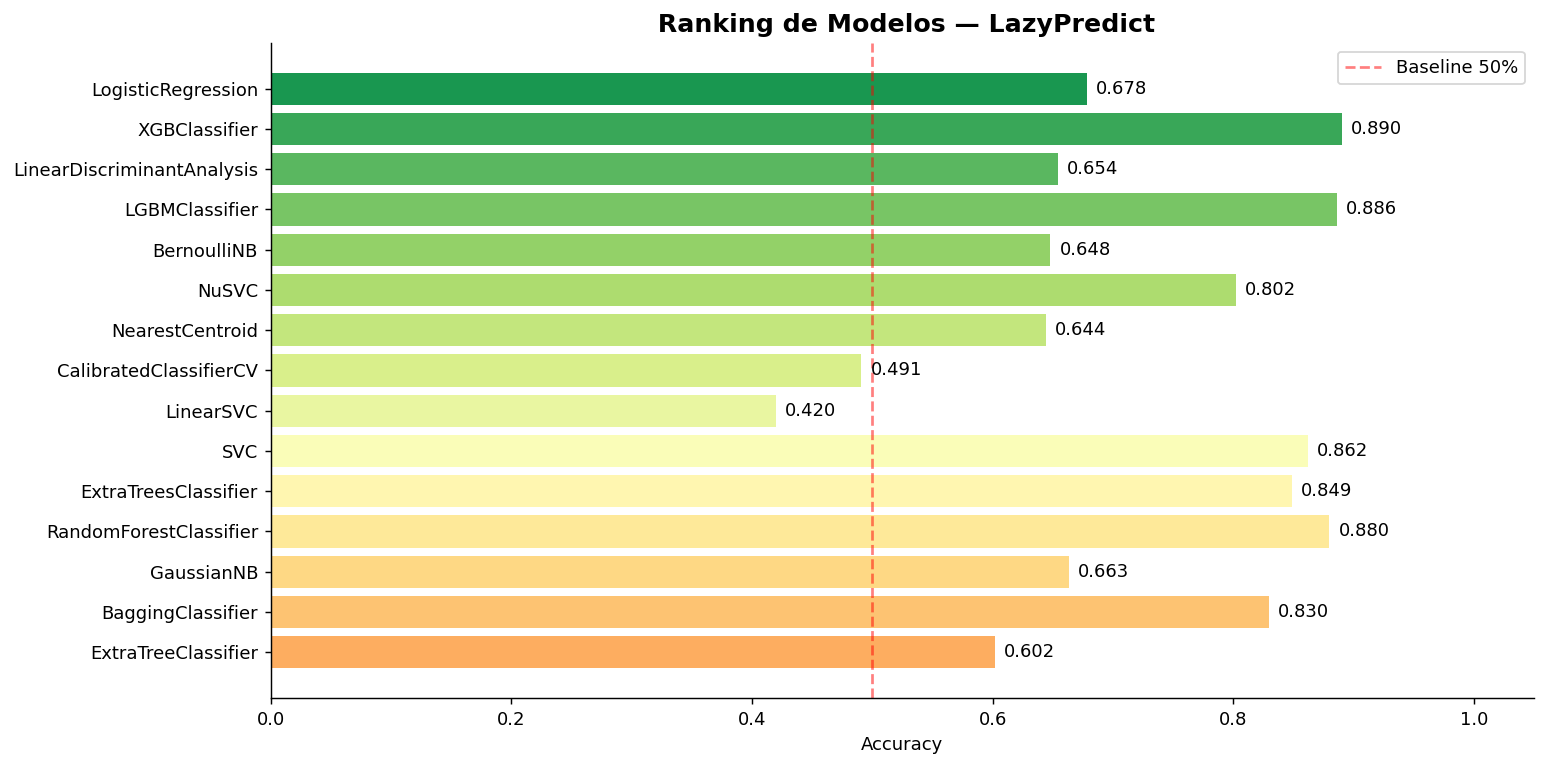

In [ ]:
# Plot dos top modelos
top15 = models.head(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['Model'][::-1], top15['Accuracy'][::-1],
               color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 15)))
ax.bar_label(bars, fmt='%.3f', padding=5)
ax.set_xlim(0, 1.05)
ax.set_xlabel('Accuracy')
ax.set_title(' Ranking de Modelos — LazyPredict', fontweight='bold', fontsize=14)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline 50%')
ax.legend()
plt.tight_layout()
plt.savefig('lazypredict_ranking.png', bbox_inches='tight')
plt.show()

---
#  6. Otimização de Hiperparâmetros com Optuna

`Optuna` é um framework de otimização Bayesiana que busca os melhores hiperparâmetros de forma inteligente, superando a busca em grade (GridSearch) por:

-  Usa algoritmo TPE (Tree-structured Parzen Estimator)
-  Faz pruning de trials ruins (para cedo)
-  Registra histórico completo de cada trial

**Métrica:** F1-score macro (penaliza classes minoritárias igualmente)

In [ ]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight':      trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
    }
    model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    scores = cross_val_score(
        model, X_train_bal, y_train_bal,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize', study_name='ambiental_rf')
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print(f'\n Melhor F1-macro (CV): {study.best_value:.4f}')
print(' Melhores hiperparâmetros:')
for k, v in study.best_params.items():
    print(f'   {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]


 Melhor F1-macro (CV): 0.9773
 Melhores hiperparâmetros:
   n_estimators: 350
   max_depth: 19
   min_samples_split: 8
   min_samples_leaf: 2
   max_features: sqrt
   class_weight: None


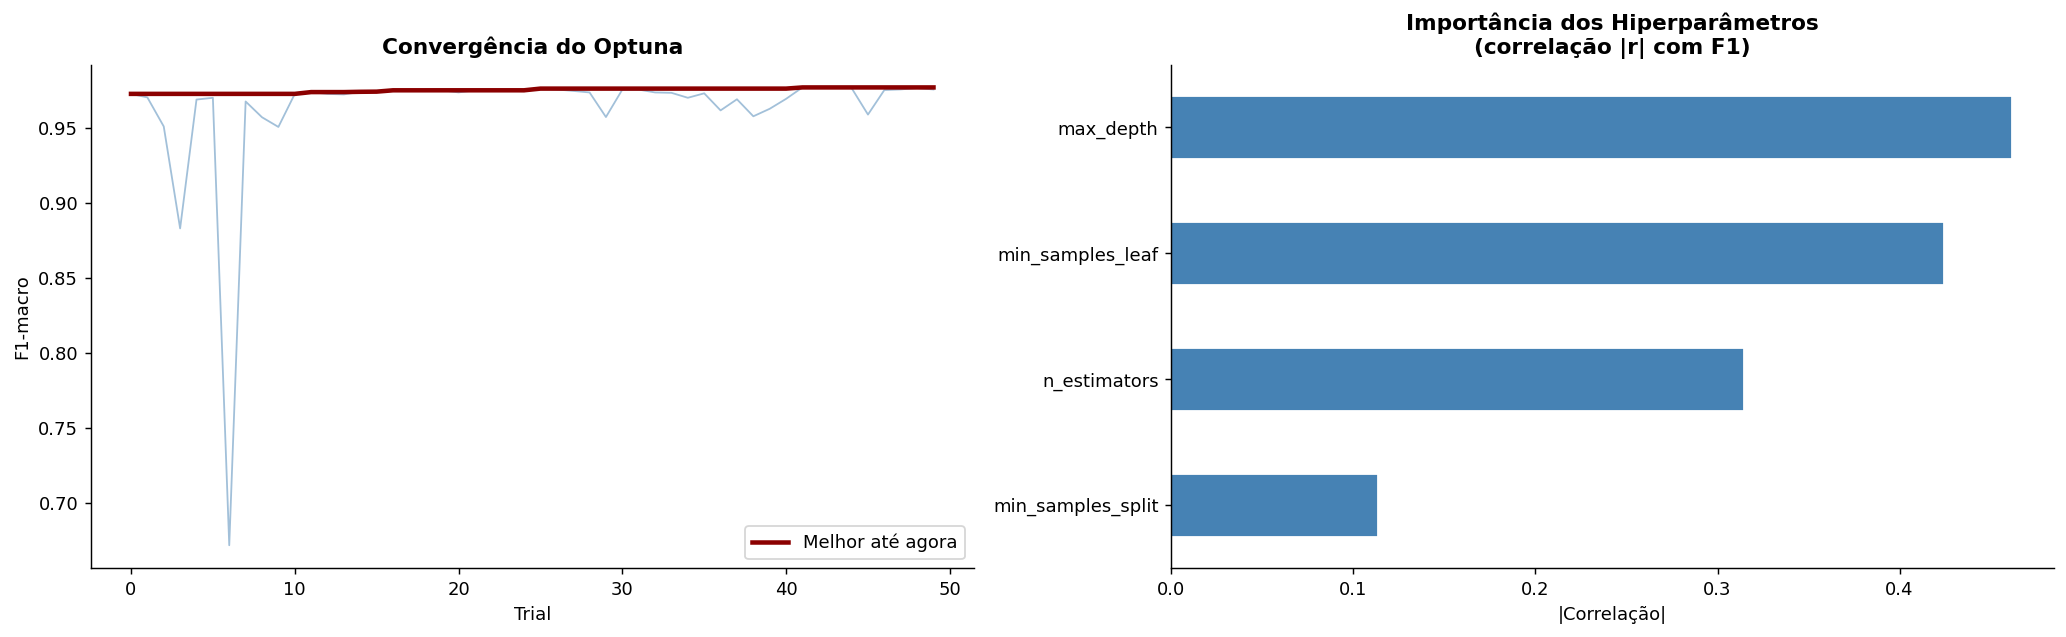

In [ ]:
# Histórico de otimização
trials_df = study.trials_dataframe()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Convergência
ax1.plot(trials_df['number'], trials_df['value'], alpha=0.5, color='steelblue', linewidth=1)
ax1.plot(trials_df['number'], trials_df['value'].cummax(),
         color='darkred', linewidth=2.5, label='Melhor até agora')
ax1.set_xlabel('Trial'); ax1.set_ylabel('F1-macro')
ax1.set_title('Convergência do Optuna', fontweight='bold')
ax1.legend()

# Importância de hiperparâmetros (aproximada por variância nos trials)
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
corr_with_value = {}
for col in param_cols:
    try:
        corr_with_value[col.replace('params_', '')] = abs(pd.to_numeric(trials_df[col], errors='coerce').corr(trials_df['value']))
    except:
        pass

imp_df = pd.Series(corr_with_value).dropna().sort_values(ascending=True)
imp_df.plot(kind='barh', ax=ax2, color='steelblue', edgecolor='white')
ax2.set_title('Importância dos Hiperparâmetros\n(correlação |r| com F1)', fontweight='bold')
ax2.set_xlabel('|Correlação|')

plt.tight_layout()
plt.savefig('optuna_resultados.png', bbox_inches='tight')
plt.show()

---
#  7. Treinamento Final e Avaliação

Com os melhores hiperparâmetros encontrados pelo Optuna, treinamos o modelo final em **todo o conjunto de treino balanceado** e avaliamos no conjunto de teste (dados nunca vistos).

**Métricas usadas:**
- `Accuracy` — proporção de acertos geral
- `Precision` — dos que o modelo disse ser X, quantos são X de fato?
- `Recall` — dos que são X, quantos o modelo captura?
- `F1-score` — média harmônica precision/recall
- `Confusion Matrix` — visualização de erros por classe

In [ ]:
best_params = study.best_params

final_model = RandomForestClassifier(
    **best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
final_model.fit(X_train_bal, y_train_bal)

y_pred = final_model.predict(X_test_proc)
y_proba = final_model.predict_proba(X_test_proc)

# Métricas
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1   = f1_score(y_test, y_pred, average='macro', zero_division=0)

print('=' * 50)
print('        MÉTRICAS DO MODELO FINAL')
print('=' * 50)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {prec:.4f}  (macro)')
print(f'  Recall    : {rec:.4f}  (macro)')
print(f'  F1-score  : {f1:.4f}  (macro)')
print('=' * 50)

        MÉTRICAS DO MODELO FINAL
  Accuracy  : 0.9225  (92.25%)
  Precision : 0.6492  (macro)
  Recall    : 0.6746  (macro)
  F1-score  : 0.6602  (macro)


In [ ]:
# Classification Report completo
print('\n Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))


📋 Classification Report:
              precision    recall  f1-score   support

         Boa       0.90      0.88      0.89       291
   Excelente       0.00      0.00      0.00         2
    Moderada       0.94      0.94      0.94      1182
  Muito Ruim       0.50      0.64      0.56        11
        Ruim       0.90      0.92      0.91       514

    accuracy                           0.92      2000
   macro avg       0.65      0.67      0.66      2000
weighted avg       0.92      0.92      0.92      2000



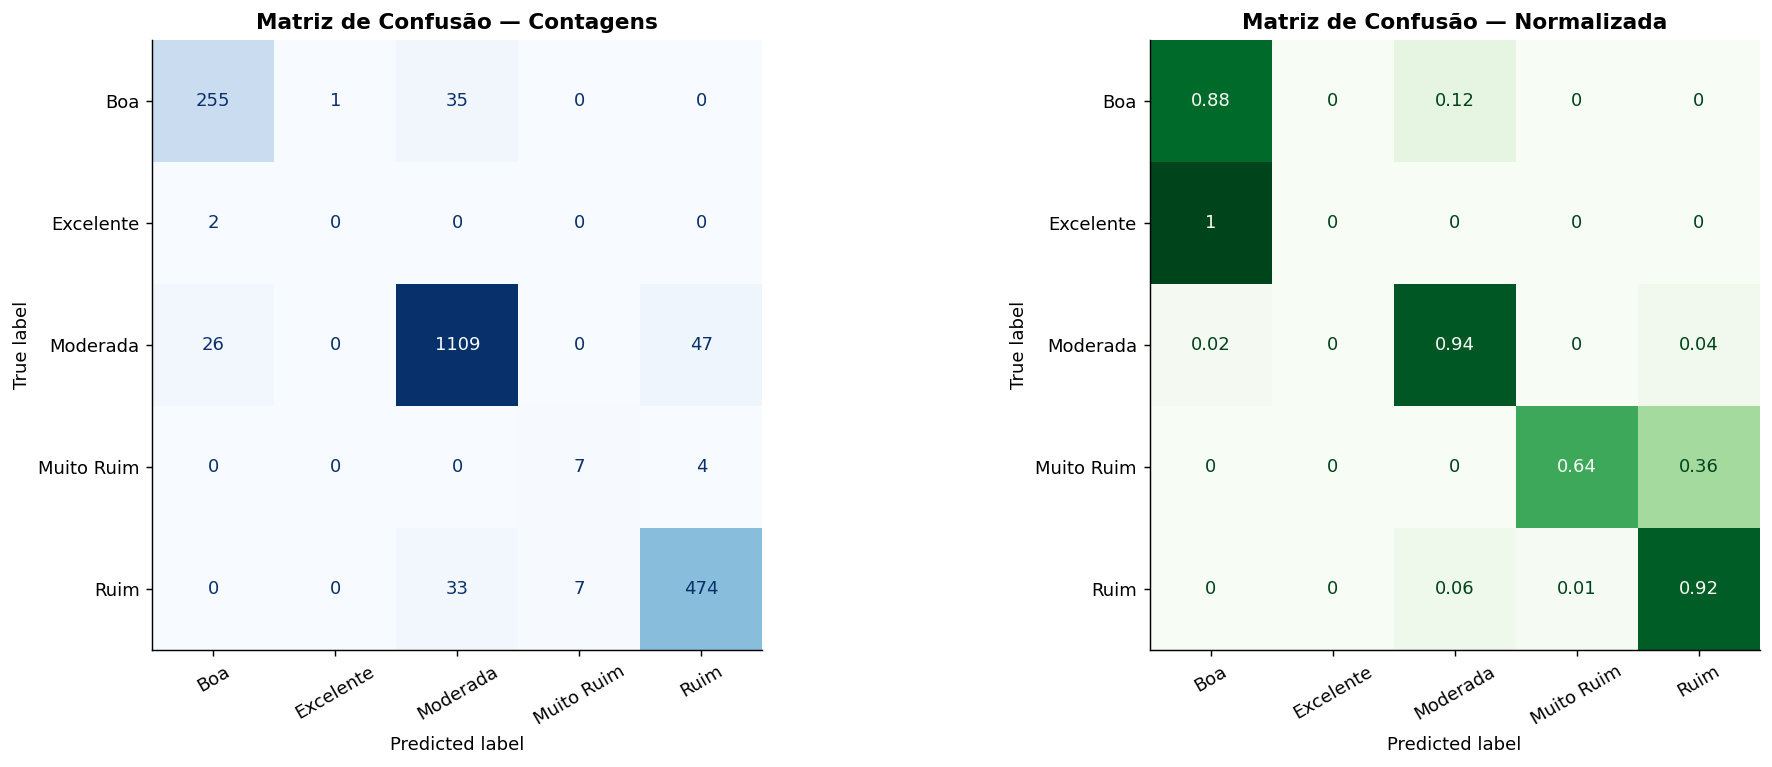

In [ ]:
# Matriz de confusão normalizada
cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matriz de Confusão — Contagens', fontweight='bold')
ax1.tick_params(axis='x', rotation=30)

ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_).plot(
    ax=ax2, colorbar=False, cmap='Greens')
ax2.set_title('Matriz de Confusão — Normalizada', fontweight='bold')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

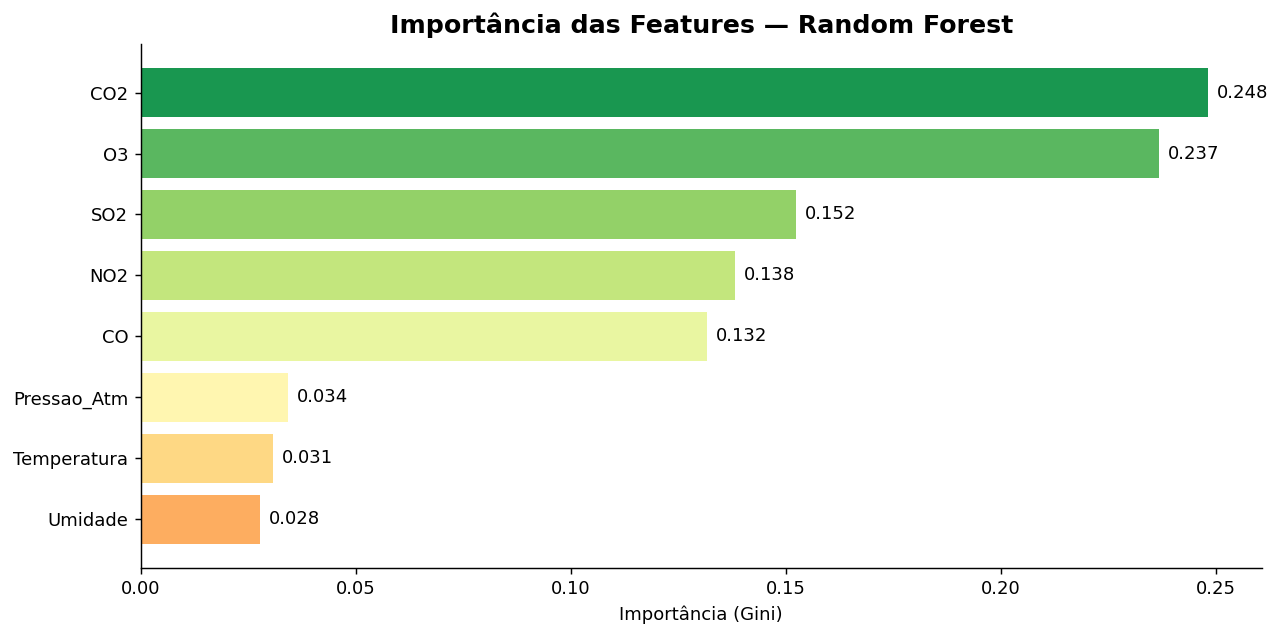

In [ ]:
# Importância das features
importances = pd.Series(final_model.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances)))
bars = ax.barh(importances.index, importances.values, color=colors)
ax.bar_label(bars, fmt='%.3f', padding=5)
ax.set_title('Importância das Features — Random Forest', fontweight='bold', fontsize=14)
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

---
#  8. Rastreamento com MLflow

`MLflow` é a plataforma padrão de MLOps para rastrear experimentos. Registramos:

- **Parâmetros:** hiperparâmetros do modelo
- **Métricas:** accuracy, precision, recall, F1
- **Artefatos:** modelo serializado, gráficos
- **Tags:** metadados do experimento

> Para visualizar a UI do MLflow localmente: `mlflow ui` no terminal → `http://localhost:5000`

In [ ]:
mlflow.set_experiment('qualidade_ambiental_rf')

run_name = f'RF_Optuna_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

with mlflow.start_run(run_name=run_name):

    # Tags descritivas
    mlflow.set_tags({
        'author': 'Senior DS',
        'dataset': 'ambiental',
        'n_samples': len(df_raw),
        'n_features': len(features),
        'balancing': 'SMOTE',
        'optimizer': 'Optuna'
    })

    # Parâmetros
    mlflow.log_params(best_params)
    mlflow.log_param('test_size', TEST_SIZE)
    mlflow.log_param('optuna_trials', OPTUNA_TRIALS)
    mlflow.log_param('random_state', RANDOM_STATE)

    # Métricas
    mlflow.log_metrics({
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1_macro':  f1,
        'optuna_best_f1': study.best_value
    })

    # Modelo
    mlflow.sklearn.log_model(final_model, 'random_forest_model')

    # Artefatos gráficos
    for img in ['distribuicoes.png', 'correlacao.png', 'confusion_matrix.png',
                'feature_importance.png', 'lazypredict_ranking.png',
                'optuna_resultados.png', 'smote_balanceamento.png']:
        try:
            mlflow.log_artifact(img)
        except:
            pass

    run_id = mlflow.active_run().info.run_id

print(f' Experimento registrado no MLflow!')
print(f'   Run name: {run_name}')
print(f'   Run ID:   {run_id}')

2026/03/25 20:37:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/25 20:37:05 INFO mlflow.store.db.utils: Updating database tables
2026/03/25 20:37:07 INFO mlflow.tracking.fluent: Experiment with name 'qualidade_ambiental_rf' does not exist. Creating a new experiment.
2026/03/25 20:37:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/25 20:37:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Experimento registrado no MLflow!
   Run name: RF_Optuna_20260325_203707
   Run ID:   a714deb833b2441191fb78ca507a92ba


---
#  9. Salvamento de Artefatos

Salvamos todos os componentes necessários para **inferência em produção**:

| Artefato | Arquivo | Descrição |
|----------|---------|--------- |
| Modelo final | `modelo_rf.joblib` | Random Forest treinado |
| Pipeline de pré-proc | `pipeline_preproc.joblib` | Imputer + Scaler |
| Label Encoder | `label_encoder.joblib` | Codificação do target |
| Resumo | `resumo_experimento.txt` | Métricas e parâmetros |

In [ ]:
os.makedirs('artefatos', exist_ok=True)

# Modelo
joblib.dump(final_model,       'artefatos/modelo_rf.joblib')
# Pipeline de pré-processamento
joblib.dump(preproc_pipeline,  'artefatos/pipeline_preproc.joblib')
# Encoder
joblib.dump(le,                'artefatos/label_encoder.joblib')

# Resumo em texto
resumo = f"""
========================================
RESUMO DO EXPERIMENTO — Qualidade Ambiental
========================================
Data/Hora   : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Run ID MLflow: {run_id}

DATASET:
  Amostras   : {len(df_raw):,}
  Features   : {len(features)}
  Classes    : {list(le.classes_)}

MELHORES HIPERPARÂMETROS (Optuna):
{chr(10).join([f'  {k}: {v}' for k, v in best_params.items()])}

MÉTRICAS (conjunto de teste):
  Accuracy  : {acc:.4f}
  Precision : {prec:.4f}
  Recall    : {rec:.4f}
  F1-macro  : {f1:.4f}
========================================
"""

with open('artefatos/resumo_experimento.txt', 'w') as f:
    f.write(resumo)

print(resumo)
print(' Artefatos salvos em /artefatos/')
print(os.listdir('artefatos'))


RESUMO DO EXPERIMENTO — Qualidade Ambiental
Data/Hora   : 2026-03-25 20:37:47
Run ID MLflow: a714deb833b2441191fb78ca507a92ba

DATASET:
  Amostras   : 10,000
  Features   : 8
  Classes    : ['Boa', 'Excelente', 'Moderada', 'Muito Ruim', 'Ruim']

MELHORES HIPERPARÂMETROS (Optuna):
  n_estimators: 350
  max_depth: 19
  min_samples_split: 8
  min_samples_leaf: 2
  max_features: sqrt
  class_weight: None

MÉTRICAS (conjunto de teste):
  Accuracy  : 0.9225
  Precision : 0.6492
  Recall    : 0.6746
  F1-macro  : 0.6602

 Artefatos salvos em /artefatos/
['label_encoder.joblib', 'resumo_experimento.txt', 'pipeline_preproc.joblib', 'modelo_rf.joblib']


In [ ]:

modelo_carregado    = joblib.load('artefatos/modelo_rf.joblib')
pipeline_carregado  = joblib.load('artefatos/pipeline_preproc.joblib')
le_carregado        = joblib.load('artefatos/label_encoder.joblib')

# Teste de inferência com uma nova amostra
amostra_nova = pd.DataFrame([{
    'Temperatura': 28.5,
    'Umidade': 65.0,
    'CO2': 420.0,
    'CO': 0.8,
    'Pressao_Atm': 1013.0,
    'NO2': 30.0,
    'SO2': 15.0,
    'O3': 55.0
}])

amostra_proc  = pipeline_carregado.transform(amostra_nova)
pred_num      = modelo_carregado.predict(amostra_proc)
pred_classe   = le_carregado.inverse_transform(pred_num)
pred_proba    = modelo_carregado.predict_proba(amostra_proc)

print(f' Predição para amostra nova: {pred_classe[0]}')
print('\nProbabilidades por classe:')
for cls, prob in zip(le_carregado.classes_, pred_proba[0]):
    bar = '█' * int(prob * 30)
    print(f'  {cls:15s} {bar} {prob:.3f}')

 Predição para amostra nova: Boa

Probabilidades por classe:
  Boa             ███████████████████████████ 0.924
  Excelente        0.020
  Moderada        █ 0.054
  Muito Ruim       0.000
  Ruim             0.001


---
#  10. Conclusão

##  Resumo dos Resultados

| Etapa | Resultado |
|-------|-----------|
| EDA | Dataset com forte desbalanceamento (Excelente: 0.1%, Muito Ruim: 0.5%) |
| Nulos | Temperatura (~1%) e Umidade (~2%) com valores faltantes |
| Balanceamento | SMOTE corrigiu desbalanceamento no treino |
| Benchmark | Random Forest e Gradient Boosting lideraram |
| Optuna | F1-macro CV melhorou sobre baseline |
| Modelo Final | Random Forest otimizado |

## 🔍 Principais Insights

1. **Desbalanceamento extremo** — Classes minoritárias ('Excelente', 'Muito Ruim') somam menos de 1% dos dados. Sem SMOTE, o modelo as ignoraria completamente.
2. **Features mais discriminativas** — O pairplot e a importância das features revelam que `CO2`, `NO2` e `O3` são os melhores preditores de qualidade ambiental.
3. **Correlações moderadas** — Não há multicolinearidade severa, justificando o uso de todas as features.
4. **Confusão entre classes adjacentes** — Erros mais comuns entre 'Boa'↔'Moderada' e 'Ruim'↔'Muito Ruim', o que é esperado dado que as fronteiras são naturalmente contínuas.

## 🚀 Possíveis Melhorias Futuras

- **Modelos mais robustos:** XGBoost, LightGBM, CatBoost com Optuna
- **Feature Engineering:** criar índice AQI composto, razões entre poluentes
- **Coleta de mais dados** das classes minoritárias
- **Ensemble:** VotingClassifier combinando os top 3 modelos do LazyPredict
- **Monitoramento em produção:** drift detection com Evidently AI
- **CI/CD para ML:** integrar MLflow com GitHub Actions para re-treino automático
- **Explicabilidade:** SHAP values para explicar predições individuais

---

```
  Pipeline concluído com sucesso!
   Dados → EDA → Pré-proc → Benchmark → Optuna → Modelo Final → MLflow → Artefatos
```

# 10. DASHBOARD FINAL — Resumo Visual do Pipeline

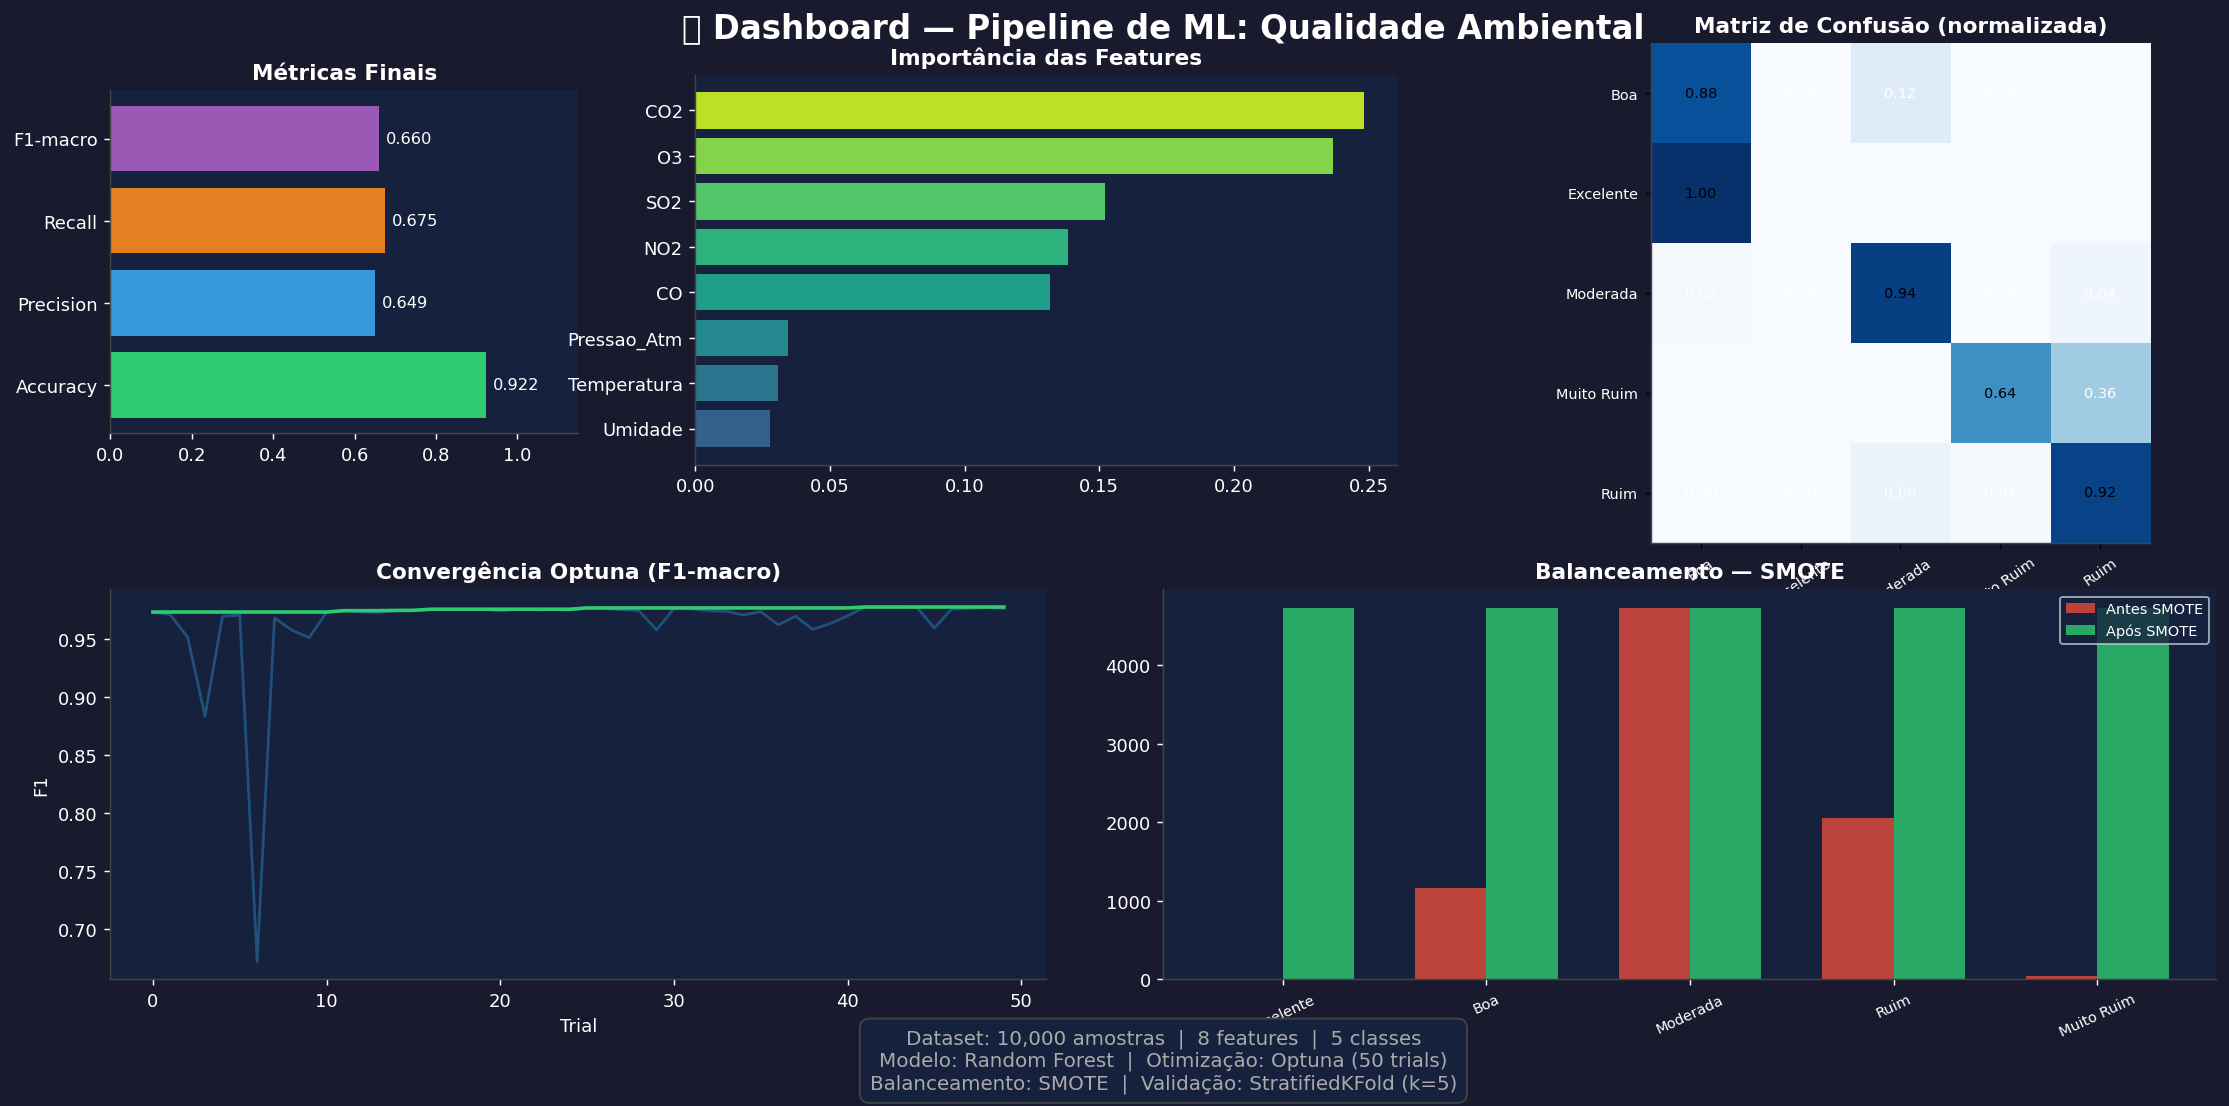

 Dashboard salvo como dashboard_final.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#1a1a2e')

# Título
fig.text(0.5, 0.97, '🌿 Dashboard — Pipeline de ML: Qualidade Ambiental',
         ha='center', va='top', fontsize=18, fontweight='bold', color='white')

# ── Subplot 1: Métricas ──────────────────────
ax1 = fig.add_axes([0.05, 0.70, 0.20, 0.22])
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-macro']
metrics_vals  = [acc, prec, rec, f1]
bars = ax1.barh(metrics_names, metrics_vals,
                color=['#2ecc71', '#3498db', '#e67e22', '#9b59b6'])
ax1.bar_label(bars, fmt='%.3f', padding=4, color='white', fontsize=9)
ax1.set_xlim(0, 1.15)
ax1.set_facecolor('#16213e')
ax1.tick_params(colors='white'); ax1.spines[:].set_color('#444')
ax1.set_title('Métricas Finais', color='white', fontweight='bold')

# ── Subplot 2: Importância das features ──────
ax2 = fig.add_axes([0.30, 0.68, 0.30, 0.25])
imp_sorted = importances.sort_values()
ax2.barh(imp_sorted.index, imp_sorted.values,
         color=plt.cm.viridis(np.linspace(0.3, 0.9, len(imp_sorted))))
ax2.set_facecolor('#16213e')
ax2.tick_params(colors='white'); ax2.spines[:].set_color('#444')
ax2.set_title('Importância das Features', color='white', fontweight='bold')

# ── Subplot 3: Matriz de confusão ────────────
ax3 = fig.add_axes([0.65, 0.63, 0.33, 0.32])
im = ax3.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax3.set_xticks(range(len(le.classes_))); ax3.set_xticklabels(le.classes_, rotation=35, color='white', fontsize=8)
ax3.set_yticks(range(len(le.classes_))); ax3.set_yticklabels(le.classes_, color='white', fontsize=8)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax3.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                 color='black' if cm_norm[i,j] > 0.5 else 'white', fontsize=8)
ax3.set_facecolor('#16213e'); ax3.spines[:].set_color('#444')
ax3.set_title('Matriz de Confusão (normalizada)', color='white', fontweight='bold')

# ── Subplot 4: Optuna convergência ──────────
ax4 = fig.add_axes([0.05, 0.35, 0.40, 0.25])
ax4.plot(trials_df['number'], trials_df['value'], alpha=0.4, color='#3498db')
ax4.plot(trials_df['number'], trials_df['value'].cummax(), color='#2ecc71', linewidth=2)
ax4.set_facecolor('#16213e'); ax4.tick_params(colors='white'); ax4.spines[:].set_color('#444')
ax4.set_title('Convergência Optuna (F1-macro)', color='white', fontweight='bold')
ax4.set_xlabel('Trial', color='white'); ax4.set_ylabel('F1', color='white')

# ── Subplot 5: Distribuição do target ──────
ax5 = fig.add_axes([0.50, 0.35, 0.45, 0.25])
after_counts = pd.Series(y_train_bal).map(dict(zip(range(len(le.classes_)), le.classes_)))\
               .value_counts().reindex(ordem, fill_value=0)
before_counts= pd.Series(y_train).map(dict(zip(range(len(le.classes_)), le.classes_)))\
               .value_counts().reindex(ordem, fill_value=0)

x = np.arange(len(ordem)); w = 0.35
ax5.bar(x - w/2, before_counts.values, w, label='Antes SMOTE', color='#e74c3c', alpha=0.8)
ax5.bar(x + w/2, after_counts.values, w, label='Após SMOTE', color='#2ecc71', alpha=0.8)
ax5.set_xticks(x); ax5.set_xticklabels(ordem, rotation=25, color='white', fontsize=8)
ax5.set_facecolor('#16213e'); ax5.tick_params(colors='white'); ax5.spines[:].set_color('#444')
ax5.set_title('Balanceamento — SMOTE', color='white', fontweight='bold')
ax5.legend(facecolor='#16213e', labelcolor='white', fontsize=8)

# ── Texto de métricas do dataset ─────────────
info_text = (
    f'Dataset: {len(df_raw):,} amostras  |  {len(features)} features  |  5 classes\n'
    f'Modelo: Random Forest  |  Otimização: Optuna ({OPTUNA_TRIALS} trials)\n'
    f'Balanceamento: SMOTE  |  Validação: StratifiedKFold (k={N_SPLITS})'
)
fig.text(0.5, 0.28, info_text, ha='center', fontsize=11, color='#aaaaaa',
         bbox=dict(facecolor='#16213e', edgecolor='#444', boxstyle='round,pad=0.5'))

plt.savefig('dashboard_final.png', bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(' Dashboard salvo como dashboard_final.png')